# 07 - Comparacao dos modelos finais

Compara os modelos finais registrados no MLflow para Random Forest Regressor e XGBoost Regressor. A tabela inclui metricas de erro, ganho contra baseline e tamanho do artefato do modelo.

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
UTILS_DIR = next(
    (candidate / "utils" for candidate in [NOTEBOOK_DIR, *NOTEBOOK_DIR.parents] if (candidate / "utils").is_dir()),
    None,
)
if UTILS_DIR is None:
    raise RuntimeError("Nao encontrei ml/notebooks/utils. Execute o notebook dentro do repositorio Saltim.")
sys.path.insert(0, str(UTILS_DIR))

import pandas as pd

from regressor_tuning_common import (
    compare_final_model_runs,
    log_final_model_comparison,
    plot_final_model_comparison,
)


## Comparacao registrada no MLflow

Execute os notebooks `05` e `06` antes deste notebook. A comparacao usa os runs champion mais recentes de cada experimento final.

In [2]:
comparison = compare_final_model_runs()

if comparison.empty:
    display(pd.DataFrame({"aviso": ["Nenhum run champion encontrado. Execute os notebooks 05 e 06 primeiro."]}))
else:
    display(
        comparison[[
            "model",
            "dataset_mode",
            "test_rmse",
            "test_mae",
            "test_r2",
            "best_cv_rmse",
            "baseline_test_rmse",
            "test_rmse_gain_vs_baseline",
            "model_size_mb",
            "registered_model_name",
            "run_id",
        ]]
    )


,model,dataset_mode,test_rmse,test_mae,test_r2,best_cv_rmse,baseline_test_rmse,test_rmse_gain_vs_baseline,model_size_mb,registered_model_name,run_id
0,Random Forest Regressor,full,0.045343,0.034145,0.801977,0.053637,0.046108,0.000764,30.400693,saltim_two_stage_05_random_forest_regressor_th...,018402e73c3b4146afe839d2907b0633
1,XGBoost Regressor,full,0.046962,0.035402,0.787586,0.054655,0.051662,0.004700,0.316792,saltim_two_stage_06_xgboost_regressor_threshol...,58db15b4b9364e6cb1bf7d9ebe65f922


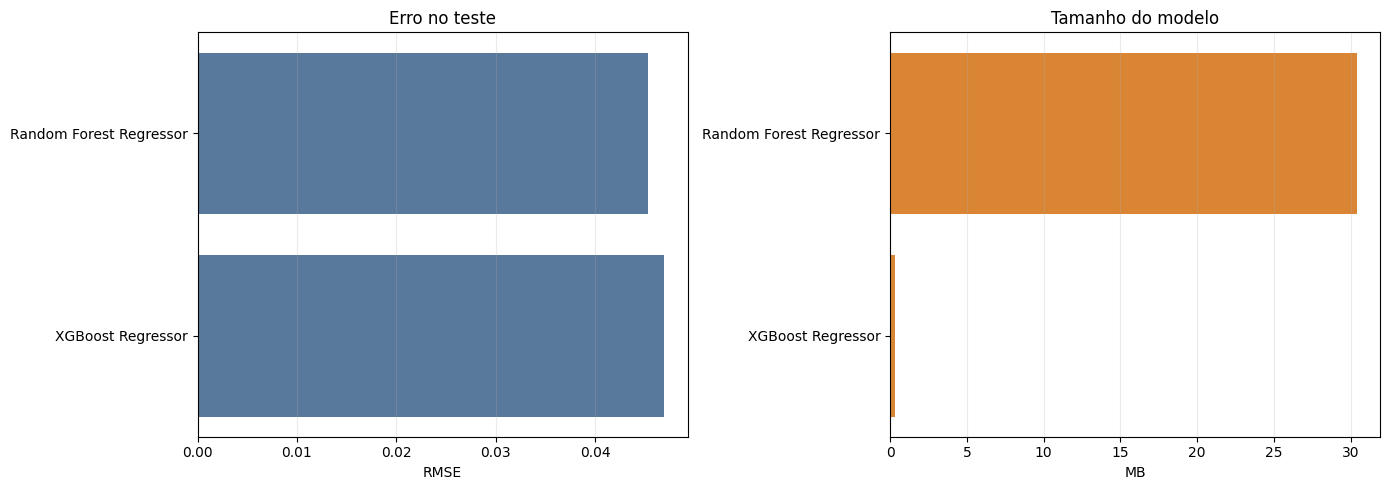

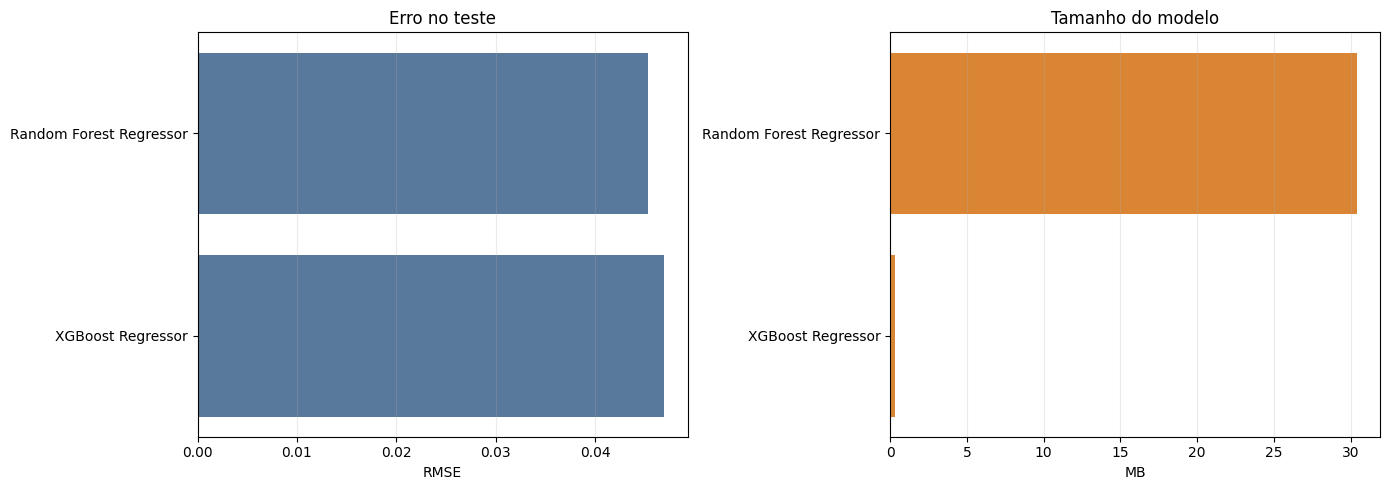

In [3]:
comparison_plot = plot_final_model_comparison(comparison)
comparison_plot


In [4]:
comparison_mlflow_info = log_final_model_comparison(comparison, comparison_plot)
comparison_mlflow_info


2026/06/01 21:48:58 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


🏃 View run 07_modelos_finais_comparison - analysis at: http://localhost:5000/#/experiments/25/runs/1a9489c133aa444ab5c9ae99c0feba9d
🧪 View experiment at: http://localhost:5000/#/experiments/25


{'run_id': '1a9489c133aa444ab5c9ae99c0feba9d',
 'comparison_artifact_path': 'comparison/final_model_comparison.csv'}

## Ranking

O ranking principal usa menor `test_rmse`. Em caso de desempenho parecido, `model_size_mb` ajuda a escolher um modelo mais leve para servir em producao.

In [5]:
if not comparison.empty:
    ranking = comparison.sort_values(["test_rmse", "model_size_mb"], ascending=[True, True]).reset_index(drop=True)
    ranking.insert(0, "rank", ranking.index + 1)
    display(ranking[["rank", "model", "test_rmse", "model_size_mb", "model_uri"]])


,rank,model,test_rmse,model_size_mb,model_uri
0,1,Random Forest Regressor,0.045343,30.400693,runs:/018402e73c3b4146afe839d2907b0633/model
1,2,XGBoost Regressor,0.046962,0.316792,runs:/58db15b4b9364e6cb1bf7d9ebe65f922/model
